In [ ]:
# install dependencies (run once)
!pip install -q timm transformers

# mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Path to your ZIP file (
zip_path = '/content/drive/MyDrive/Structured3D_panorama_17.zip'
extract_dir = '/content/extracted_scene_17'  # Where to unzip

# Verify the file exists
import os
if not os.path.exists(zip_path):
    print(f" Error: File not found at {zip_path}")
else:
    print(f" Found: {zip_path} (Size: {os.path.getsize(zip_path)/1e9:.2f} GB)")

 Found: /content/drive/MyDrive/Structured3D_panorama_17.zip (Size: 6.83 GB)


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Structured3D_panorama_17.zip'
extract_dir = '/content/panorama_17'  # Extraction folder

# Create directory (if it doesn't exist)
os.makedirs(extract_dir, exist_ok=True)

# Extract with progress
try:
    print(" Extracting... (this may take a while for 6.83GB)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(" Extraction complete!")
    print(f"Files extracted to: {extract_dir}")
except zipfile.BadZipFile:
    print(" Error: ZIP file is corrupted!")
except Exception as e:
    print(f" Unexpected error: {str(e)}")

 Extracting... (this may take a while for 6.83GB)
 Extraction complete!
Files extracted to: /content/panorama_17


In [ ]:
# Find all JPGs in the extracted folder
panorama_images = []
for root, _, files in os.walk(extract_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.png')):
            panorama_images.append(os.path.join(root, file))

print(f"Found {len(panorama_images)} images. Examples:")
print(panorama_images[:3])  # Show first 3

Found 14112 images. Examples:
['/content/panorama_17/Structured3D/scene_03425/2D_rendering/324/panorama/empty/rgb_warmlight.png', '/content/panorama_17/Structured3D/scene_03425/2D_rendering/324/panorama/empty/rgb_coldlight.png', '/content/panorama_17/Structured3D/scene_03425/2D_rendering/324/panorama/empty/depth.png']


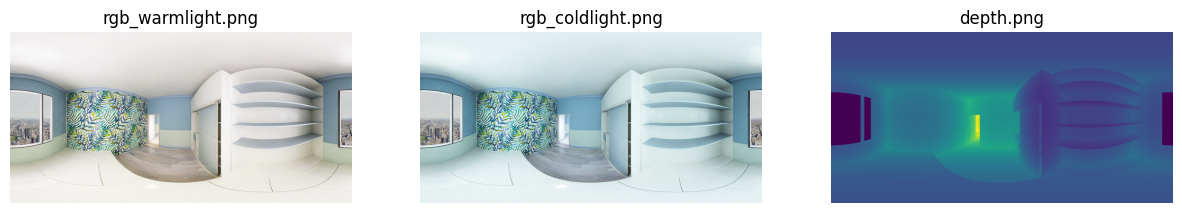

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load first 3 images
sample_images = panorama_images[:3]
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(sample_images, 1):
    img = Image.open(img_path)
    plt.subplot(1, 3, i)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')
plt.show()

In [ ]:
import os

print("Current working directory:", os.getcwd())
print("\nContents of /content:")
print(os.listdir("/content"))

if os.path.exists("/content/panorama_17"):
    print("\nContents of /content/panorama_17:")
    print(os.listdir("/content/panorama_17")[:20])
else:
    print("\n❌ Folder /content/panorama_17 does not exist")


Current working directory: /content

Contents of /content:
['.config', 'panorama_17', 'drive', 'sample_data']

Contents of /content/panorama_17:
['Structured3D']


In [ ]:
import os

structured3d_path = "/content/panorama_17/Structured3D"
for root, dirs, files in os.walk(structured3d_path):
    for f in files:
        if f.lower().endswith(('.jpg', '.png')):
            print("Found image at:", os.path.join(root, f))
            raise SystemExit  # Stop after finding the first image
print("❌ No images found inside Structured3D")


Found image at: /content/panorama_17/Structured3D/scene_03425/2D_rendering/324/panorama/empty/rgb_warmlight.png


SystemExit: 

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
import os
from PIL import Image
import torch
import torchvision.transforms as transforms

# ✅ 1. Find first image in correct folder
def find_first_image(directory="/content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple"):
    for file in os.listdir(directory):
        if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif")):
            return os.path.join(directory, file)
    raise FileNotFoundError("❌ No image file found in the directory. Please check preprocessing.")

# ✅ 2. Load and resize image
def load_and_resize_image_auto(size=(224, 224)):
    image_path = find_first_image("/content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple")
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor()
    ])
    return transform(image).unsqueeze(0)

# ✅ 3. Extract patches
def extract_patches(img_tensor, patch_size=16):
    B, C, H, W = img_tensor.shape
    assert H % patch_size == 0 and W % patch_size == 0, "Image size must be divisible by patch size."
    patches = img_tensor.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    patches = patches.contiguous().view(B, C, -1, patch_size, patch_size)
    patches = patches.permute(0, 2, 1, 3, 4).reshape(B, -1, C * patch_size * patch_size)
    return patches

# ✅ 4. Positional encoding
def get_positional_encoding(N, dim):
    pos = torch.arange(N, dtype=torch.float32).unsqueeze(1)
    i = torch.arange(dim, dtype=torch.float32).unsqueeze(0)
    angle_rates = 1 / torch.pow(10000, (2 * (i // 2)) / dim)
    angle_rads = pos * angle_rates
    pe = torch.zeros_like(angle_rads)
    pe[:, 0::2] = torch.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = torch.cos(angle_rads[:, 1::2])
    return pe.unsqueeze(0)

# ✅ 5. Run pipeline
image_tensor = load_and_resize_image_auto(size=(224, 224))
patches = extract_patches(image_tensor, patch_size=16)
B, N, patch_dim = patches.shape
positional_embeddings = get_positional_encoding(N, patch_dim)

print("🔹 Image shape:", image_tensor.shape)
print("🔹 Patch shape:", patches.shape)
print("🔹 Positional Encoding shape:", positional_embeddings.shape)


🔹 Image shape: torch.Size([1, 3, 224, 224])
🔹 Patch shape: torch.Size([1, 196, 768])
🔹 Positional Encoding shape: torch.Size([1, 196, 768])


In [ ]:
from sklearn.model_selection import train_test_split
import shutil
import os

# Define where your images are located
output_dir = "/content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple"

# Get all preprocessed image paths
all_images = [os.path.join(output_dir, img) for img in os.listdir(output_dir) if img.lower().endswith((".png", ".jpg", ".jpeg"))]

# Split into 80% train, 10% val, 10% test
train, temp = train_test_split(all_images, test_size=0.2, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

# Function to copy images to subfolders
def move_images(img_list, target_folder):
    os.makedirs(target_folder, exist_ok=True)
    for img_path in img_list:
        shutil.copy(img_path, os.path.join(target_folder, os.path.basename(img_path)))

# Set up folders
split_base = output_dir
move_images(train, os.path.join(split_base, 'train'))
move_images(val, os.path.join(split_base, 'val'))
move_images(test, os.path.join(split_base, 'test'))

print("✅ Dataset split into train/val/test at:", split_base)


✅ Dataset split into train/val/test at: /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple


In [ ]:
print(f" Total images found: {len(panorama_images)}")


 Total images found: 14112


In [ ]:
annotation_files = []
for root, _, files in os.walk(extract_dir):
    for file in files:
        if file.lower().endswith('.json'):
            annotation_files.append(os.path.join(root, file))

print(f" Found {len(annotation_files)} JSON files.")
print(" Example layout/annotation file:", annotation_files[0] if annotation_files else "❌ None found")


 Found 100 JSON files.
 Example layout/annotation file: /content/panorama_17/Structured3D/scene_03425/annotation_3d.json


In [ ]:
import json

# Load a sample annotation JSON
with open(annotation_files[0], 'r') as f:
    annotation_data = json.load(f)

# Display top-level keys
print("Keys in the annotation file:", annotation_data.keys())

# Example: Show layout info (rooms, doors, etc.)
if 'layout' in annotation_data:
    print(" Layout data:")
    print(annotation_data['layout'])  # or use pprint if it's large
else:
    print(" 'layout' key not found in this file.")


Keys in the annotation file: dict_keys(['lines', 'semantics', 'junctions', 'planes', 'planeLineMatrix', 'manhattan', 'cuboids', 'lineJunctionMatrix'])
 'layout' key not found in this file.


In [ ]:
from pprint import pprint

# Show first few planes
print(" Example plane data:")
pprint(annotation_data['planes'][:2])  # Just show 2 for brevity

# Show semantics (category for each plane)
print("\n Plane Semantics:")
pprint(annotation_data['semantics']['planes'])  # should list "floor", "wall", etc.


 Example plane data:
[{'ID': 0, 'normal': [0, 0, 1], 'offset': 0, 'type': 'floor'},
 {'ID': 1, 'normal': [0, 0, -1], 'offset': 3000.0, 'type': 'ceiling'}]

 Plane Semantics:


TypeError: list indices must be integers or slices, not str

In [ ]:
from pprint import pprint

print(" Semantics field type:", type(annotation_data['semantics']))
pprint(annotation_data['semantics'])  # Check the actual content


 Semantics field type: <class 'list'>
[{'ID': 225, 'planeID': [0, 1, 13, 22, 23, 27], 'type': 'bathroom'},
 {'ID': 324, 'planeID': [2, 3, 9, 10, 29, 31], 'type': 'bedroom'},
 {'ID': 5, 'planeID': [36, 37, 38, 39], 'type': 'window'},
 {'ID': 6, 'planeID': [40, 41, 42, 43], 'type': 'door'},
 {'ID': 7, 'planeID': [44, 45, 46, 47], 'type': 'window'},
 {'ID': 8, 'planeID': [48, 49, 50, 51], 'type': 'door'},
 {'ID': 9, 'planeID': [52, 53, 54, 55], 'type': 'door'},
 {'ID': 10, 'planeID': [56, 57, 58, 59], 'type': 'window'},
 {'ID': 4, 'planeID': [32, 33, 34, 35], 'type': 'window'},
 {'ID': 159,
  'planeID': [4, 5, 7, 8, 11, 12, 16, 17, 19, 20, 21, 24, 28, 30],
  'type': 'living room'},
 {'ID': 325, 'planeID': [6, 14, 15, 18, 25, 26], 'type': 'outwall'}]


In [ ]:
# Map each plane index to its semantic type
plane_id_to_semantic = {}

for entry in annotation_data['semantics']:
    label = entry['type']
    for pid in entry['planeID']:
        plane_id_to_semantic[pid] = label

# Show a few mapped entries
from pprint import pprint
print(" Mapped plane IDs to semantic types:")
pprint({k: plane_id_to_semantic[k] for k in list(plane_id_to_semantic)[:10]})


 Mapped plane IDs to semantic types:
{0: 'bathroom',
 1: 'bathroom',
 2: 'bedroom',
 3: 'bedroom',
 9: 'bedroom',
 10: 'bedroom',
 13: 'bathroom',
 22: 'bathroom',
 23: 'bathroom',
 27: 'bathroom'}


In [ ]:
print("\n📐 Plane geometry with semantics:")
for plane in annotation_data['planes'][:10]:  # Just show 10
    pid = plane['ID']
    plane_type = plane_id_to_semantic.get(pid, 'Unknown')
    print(f"Plane ID {pid:3d}: Type = {plane_type:12s} | Normal = {plane['normal']} | Offset = {plane['offset']}")



📐 Plane geometry with semantics:
Plane ID   0: Type = bathroom     | Normal = [0, 0, 1] | Offset = 0
Plane ID   1: Type = bathroom     | Normal = [0, 0, -1] | Offset = 3000.0
Plane ID   2: Type = bedroom      | Normal = [0, 0, 1] | Offset = 0
Plane ID   3: Type = bedroom      | Normal = [0, 0, -1] | Offset = 3000.0
Plane ID   4: Type = living room  | Normal = [0, 0, 1] | Offset = 0
Plane ID   5: Type = living room  | Normal = [0, 0, -1] | Offset = 3000.0
Plane ID   6: Type = outwall      | Normal = [-1.0, -0.0, 0] | Offset = -4454.5312
Plane ID   7: Type = living room  | Normal = [1.0, 0.0, 0] | Offset = -765.46875
Plane ID   8: Type = living room  | Normal = [-0.0, -1.0, 0] | Offset = 1326.7188
Plane ID   9: Type = bedroom      | Normal = [0.0, -1.0, 0] | Offset = -773.28125


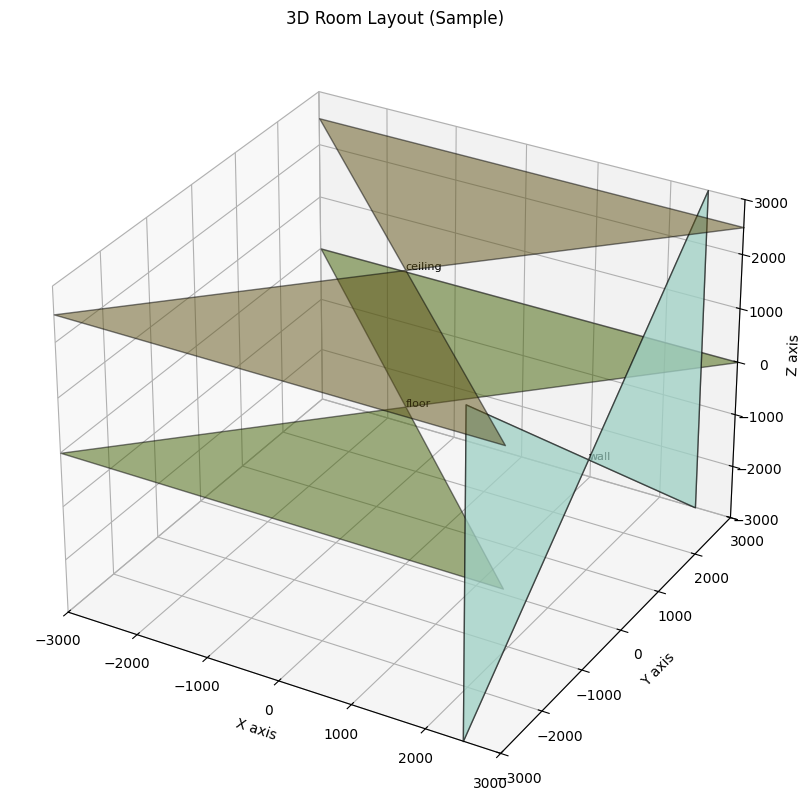

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import random

#  Sample annotation data to test
annotation_data = {
    "planes": [
        {"ID": 0, "normal": [0, 0, 1], "offset": 0, "type": "floor"},
        {"ID": 1, "normal": [0, 0, -1], "offset": -2500, "type": "ceiling"},
        {"ID": 2, "normal": [1, 0, 0], "offset": 2500, "type": "wall"},
        {"ID": 3, "normal": [-1, 0, 0], "offset": -2500, "type": "wall"}
    ]
}

# Step 1: Build the plane_id_to_semantic mapping
plane_id_to_semantic = {plane['ID']: plane['type'] for plane in annotation_data['planes']}

# Step 2: Function to assign random color per semantic type
def get_color_map(plane_id_to_semantic):
    room_types = list(set(plane_id_to_semantic.values()))
    return {room: [random.random() for _ in range(3)] for room in room_types}

# Step 3: Generate corner points of a plane
def get_plane_points(normal, offset, size=3000):
    normal = np.array(normal)
    d = offset
    if normal[2] != 0:
        v1 = np.cross(normal, [1, 0, 0])
    else:
        v1 = np.cross(normal, [0, 0, 1])
    v1 = v1 / np.linalg.norm(v1)
    v2 = np.cross(normal, v1)
    v2 = v2 / np.linalg.norm(v2)
    center = d * np.array(normal)
    return [center + dx * size * v1 + dy * size * v2 for dx in [-1, 1] for dy in [-1, 1]]

# Step 4: Plotting
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
color_map = get_color_map(plane_id_to_semantic)

for plane in annotation_data['planes']:
    pid = plane['ID']
    if pid not in plane_id_to_semantic:
        continue
    room_type = plane_id_to_semantic[pid]
    color = color_map[room_type]
    corners = get_plane_points(plane['normal'], plane['offset'])
    poly = Poly3DCollection([corners], alpha=0.5, facecolor=color, edgecolor='k')
    ax.add_collection3d(poly)
    center = np.mean(np.array(corners), axis=0)
    ax.text(*center, room_type, fontsize=8, color='black')

ax.set_xlim(-3000, 3000)
ax.set_ylim(-3000, 3000)
ax.set_zlim(-3000, 3000)
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_zlabel("Z axis")
plt.title("3D Room Layout (Sample)")
plt.show()


In [ ]:
import glob
import os

folder = "/content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/train"
images = glob.glob(os.path.join(folder, "*.png"))

if len(images) == 0:
    print("❌ No images found in:", folder)
else:
    img_path = images[0]
    print("✅ Using image:", img_path)


✅ Using image: /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/train/depth.png


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_hybrid_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_hybrid_384.pt


100%|██████████| 470M/470M [00:02<00:00, 244MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


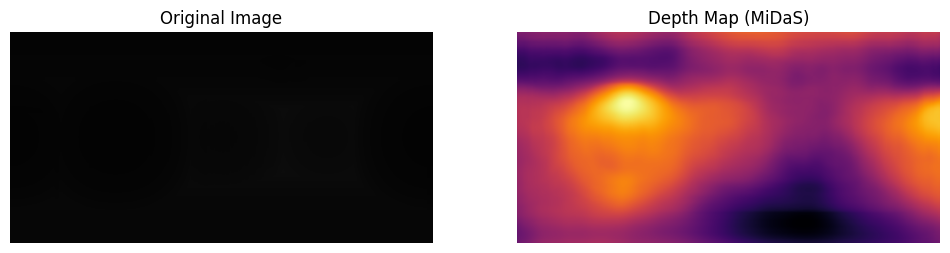

✅ Depth map saved to: /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/train/depth_depth.png


In [ ]:
import torch
import cv2
import matplotlib.pyplot as plt
from torchvision.transforms import Compose

# Load MiDaS model and transforms
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Hybrid")  # Hybrid = good quality + faster
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)
midas.eval()

# Get transforms for MiDaS input
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.dpt_transform

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
input_batch = transform(img).to(device)

# Run inference
with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False
    ).squeeze()

depth_map = prediction.cpu().numpy()

# Normalize depth for visualization
depth_min, depth_max = depth_map.min(), depth_map.max()
depth_vis = (255 * (depth_map - depth_min) / (depth_max - depth_min)).astype("uint8")

# Display
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(depth_vis, cmap="inferno")
plt.title("Depth Map (MiDaS)")
plt.axis("off")

plt.show()

# Save depth map if you want
save_path = img_path.replace(".png", "_depth.png")
cv2.imwrite(save_path, depth_vis)
print("✅ Depth map saved to:", save_path)


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import Compose

# ✅ Load MiDaS model
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Hybrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)
midas.eval()

# ✅ Load transforms
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.dpt_transform

# ✅ Define folders
base_dir = "/content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple"
folders = ["train", "val", "test"]

# ✅ Output directory for depth maps
depth_base = os.path.join(base_dir, "depth_maps")
os.makedirs(depth_base, exist_ok=True)

for folder in folders:
    input_folder = os.path.join(base_dir, folder)
    output_folder = os.path.join(depth_base, folder)
    os.makedirs(output_folder, exist_ok=True)

    image_files = [f for f in os.listdir(input_folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    print(f"📂 Processing {len(image_files)} images in {folder}/")

    for img_name in image_files:
        img_path = os.path.join(input_folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Skipping unreadable file: {img_name}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        input_batch = transform(img).to(device)

        # ✅ Inference
        with torch.no_grad():
            prediction = midas(input_batch)
            prediction = torch.nn.functional.interpolate(
                prediction.unsqueeze(1),
                size=img.shape[:2],
                mode="bicubic",
                align_corners=False
            ).squeeze()

        depth_map = prediction.cpu().numpy()

        # Normalize to 0–255
        depth_min, depth_max = depth_map.min(), depth_map.max()
        depth_vis = (255 * (depth_map - depth_min) / (depth_max - depth_min)).astype("uint8")

        # Save depth map
        save_path = os.path.join(output_folder, img_name.replace(".png", "_depth.png"))
        cv2.imwrite(save_path, depth_vis)

    print(f"✅ Finished {folder} folder → Depth maps saved to: {output_folder}\n")

print("🎉 All depth maps generated and saved successfully!")


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


📂 Processing 6 images in train/
✅ Finished train folder → Depth maps saved to: /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/depth_maps/train

📂 Processing 1 images in val/
✅ Finished val folder → Depth maps saved to: /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/depth_maps/val

📂 Processing 1 images in test/
✅ Finished test folder → Depth maps saved to: /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/depth_maps/test

🎉 All depth maps generated and saved successfully!


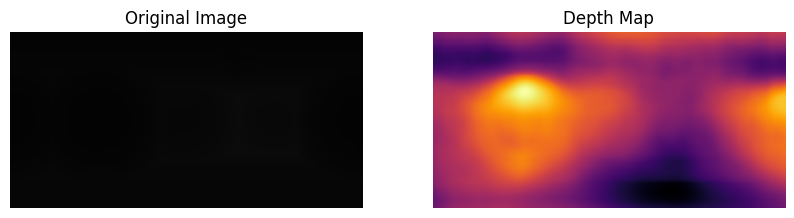

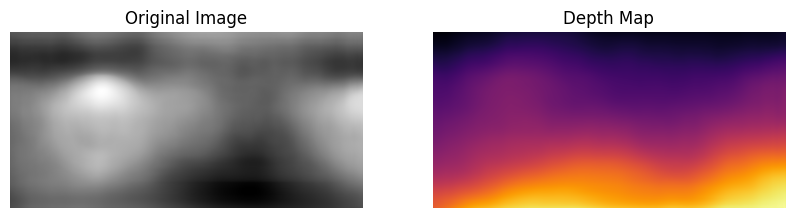

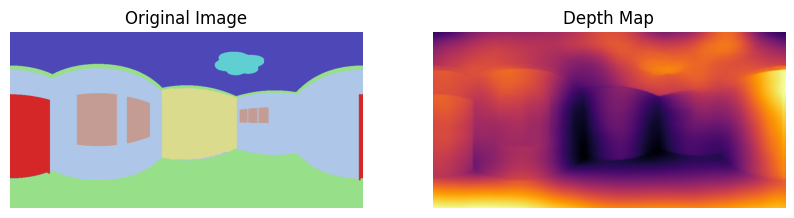

In [ ]:
import random
from matplotlib import pyplot as plt

sample_folder = os.path.join(depth_base, "train")
samples = random.sample(os.listdir(sample_folder), 3)

for s in samples:
    img_path = os.path.join(base_dir, "train", s.replace("_depth.png", ".png"))
    depth_path = os.path.join(sample_folder, s)

    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    depth = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(depth, cmap="inferno")
    plt.title("Depth Map")
    plt.axis("off")

    plt.show()


In [ ]:
import os

base_path = "/content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple"

for root, dirs, files in os.walk(base_path):
    print(f"\n📁 {root}")
    for d in dirs:
        print("   📂", d)
    for f in files[:5]:  # show only first 5 files per folder
        print("   🖼️", f)



📁 /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple
   📂 depth_maps
   📂 train
   📂 val
   📂 test
   🖼️ rgb_warmlight.png
   🖼️ rgb_coldlight.png
   🖼️ depth.png
   🖼️ normal.png
   🖼️ rgb_rawlight.png

📁 /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/depth_maps
   📂 train
   📂 val
   📂 test

📁 /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/depth_maps/train
   🖼️ rgb_rawlight_depth.png
   🖼️ depth_depth.png
   🖼️ albedo_depth.png
   🖼️ normal_depth.png
   🖼️ semantic_depth.png

📁 /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/depth_maps/val
   🖼️ rgb_warmlight_depth.png

📁 /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/depth_maps/test
   🖼️ rgb_coldlight_depth.png

📁 /content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple/train
   🖼️ depth_depth.png
   🖼️ depth.png
   🖼️ normal.png
   🖼️ rgb_rawlight.p

In [ ]:
import os

dataset_root = "/content/dataset"

folders = [
    "train/images", "train/depth_maps", "train/labels",
    "val/images", "val/depth_maps", "val/labels",
    "test/images", "test/depth_maps", "test/labels"
]

for folder in folders:
    os.makedirs(os.path.join(dataset_root, folder), exist_ok=True)

print("✅ Created clean dataset folder structure")


✅ Created clean dataset folder structure


In [ ]:
import shutil
import glob

base = "/content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple"
target = "/content/dataset"

splits = ["train", "val", "test"]

for split in splits:
    print(f"\n📂 Processing {split}...")

    # Move images
    for f in glob.glob(f"{base}/{split}/*.png"):
        if "rgb" in f:  # RGB images
            shutil.copy(f, f"{target}/{split}/images")
        elif "semantic" in f:  # Segmentation masks
            shutil.copy(f, f"{target}/{split}/labels")

    # Move depth maps
    for f in glob.glob(f"{base}/depth_maps/{split}/*.png"):
        shutil.copy(f, f"{target}/{split}/depth_maps")

print("\n✅ All files moved successfully into organized dataset folders!")



📂 Processing train...

📂 Processing val...

📂 Processing test...

✅ All files moved successfully into organized dataset folders!


In [ ]:
import os

for split in ["train", "val", "test"]:
    img_count = len(os.listdir(f"/content/dataset/{split}/images"))
    depth_count = len(os.listdir(f"/content/dataset/{split}/depth_maps"))
    label_count = len(os.listdir(f"/content/dataset/{split}/labels"))
    print(f"{split}: 🖼️ {img_count} images | 🌊 {depth_count} depth maps | 🎯 {label_count} labels")


train: 🖼️ 1 images | 🌊 6 depth maps | 🎯 1 labels
val: 🖼️ 1 images | 🌊 1 depth maps | 🎯 0 labels
test: 🖼️ 1 images | 🌊 1 depth maps | 🎯 0 labels


In [ ]:
import os

base = "/content/panorama_17/Structured3D/scene_03494/2D_rendering/1811/panorama/simple"

for split in ["train", "val", "test"]:
    print(f"\n=== {split.upper()} ===")
    print("Images:", os.listdir(f"{base}/{split}") if os.path.exists(f"{base}/{split}") else "N/A")
    print("Depth maps:", os.listdir(f"{base}/depth_maps/{split}") if os.path.exists(f"{base}/depth_maps/{split}") else "N/A")



=== TRAIN ===
Images: ['depth_depth.png', 'depth.png', 'normal.png', 'rgb_rawlight.png', 'albedo.png', 'semantic.png']
Depth maps: ['rgb_rawlight_depth.png', 'depth_depth.png', 'albedo_depth.png', 'normal_depth.png', 'semantic_depth.png', 'depth_depth_depth.png']

=== VAL ===
Images: ['rgb_warmlight.png']
Depth maps: ['rgb_warmlight_depth.png']

=== TEST ===
Images: ['rgb_coldlight.png']
Depth maps: ['rgb_coldlight_depth.png']


In [ ]:
import os

train_img_dir = "/content/dataset/train/images"
train_depth_dir = "/content/dataset/train/depth_maps"

img_files = [f.replace(".png","") for f in os.listdir(train_img_dir)]
depth_files = [f.replace("_depth.png","") for f in os.listdir(train_depth_dir)]

print("✅ Matched image-depth pairs:")
for name in img_files:
    if name in depth_files:
        print("  ", name)

print("\n⚠️ Unmatched images:")
for name in img_files:
    if name not in depth_files:
        print("  ", name)

print("\n⚠️ Unmatched depth maps:")
for name in depth_files:
    if name not in img_files:
        print("  ", name)


✅ Matched image-depth pairs:
   rgb_rawlight

⚠️ Unmatched images:

⚠️ Unmatched depth maps:
   depth
   albedo
   normal
   semantic
   depth_depth


In [ ]:
# =====================================================
# STEP 1: Imports and setup
# =====================================================
import os
import cv2
import torch
from torchvision.transforms import Compose
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import shutil

# Load MiDaS model (for depth estimation)
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Hybrid")
midas.to("cuda" if torch.cuda.is_available() else "cpu")
midas.eval()

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.dpt_transform

# =====================================================
# STEP 2: Define helper functions
# =====================================================
def generate_depth(img_path, output_dir, output_filename=None):
    """Generate depth map for one image and save it."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    img = cv2.imread(img_path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_batch = transform(img).to(device)

    with torch.no_grad():
        prediction = midas(input_batch)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth_map = prediction.cpu().numpy()
    os.makedirs(output_dir, exist_ok=True)
    if output_filename is None:
        output_filename = os.path.basename(img_path).replace(".png", "_depth.png")
    depth_file = os.path.join(output_dir, output_filename)
    cv2.imwrite(depth_file, depth_map)
    return depth_file


# =====================================================
# STEP 3: Process ALL scenes and ALL rooms, create dataset pairs
# =====================================================
base_dir = "/content/panorama_17/Structured3D"
dataset_root = "/content/dataset"  # final output dataset

# Ensure a clean slate
if os.path.exists(dataset_root):
    shutil.rmtree(dataset_root)
os.makedirs(dataset_root, exist_ok=True)

all_samples = []

# Loop through every scene
scenes = sorted([s for s in os.listdir(base_dir) if s.startswith("scene_")])

print("Collecting RGB-Semantic pairs from ALL scenes and ALL rooms...")
for scene in tqdm(scenes, desc="Processing scenes"):
    rendering_path = os.path.join(base_dir, scene, "2D_rendering")
    if not os.path.exists(rendering_path):
        continue

    # FIX: Iterate ALL rooms under each scene (not just hardcoded '1811')
    for room_id in sorted(os.listdir(rendering_path)):
        room_path = os.path.join(rendering_path, room_id)
        if not os.path.isdir(room_path):
            continue

        simple_path = os.path.join(room_path, "panorama", "simple")
        if not os.path.exists(simple_path):
            continue

        # Find semantic label
        semantic_files = [f for f in os.listdir(simple_path) if f.lower() == "semantic.png"]
        if not semantic_files:
            continue
        semantic_path_scene = os.path.join(simple_path, semantic_files[0])

        # Find all RGB images for this room
        for img_file in sorted(os.listdir(simple_path)):
            if img_file.lower().startswith("rgb_") and img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                rgb_image_path = os.path.join(simple_path, img_file)
                all_samples.append({
                    "rgb_path": rgb_image_path,
                    "semantic_path": semantic_path_scene,
                    "scene": scene,
                    "room_id": room_id,
                })

print(f"\nFound {len(all_samples)} RGB-Semantic pairs across {len(scenes)} scenes.")

# =====================================================
# STEP 4: Train/Val/Test Split on pairs
# =====================================================
if len(all_samples) < 5:
    raise ValueError(
        f"Only found {len(all_samples)} samples! Check the ZIP file contents. "
        "Expected hundreds of samples across multiple scenes and rooms."
    )

train_samples, temp_samples = train_test_split(all_samples, test_size=0.2, random_state=42)
val_samples, test_samples = train_test_split(temp_samples, test_size=0.5, random_state=42)

print(f"Split: {len(train_samples)} train / {len(val_samples)} val / {len(test_samples)} test")

# =====================================================
# STEP 5: Generate depth maps and copy files for all splits
# =====================================================
splits_data = {"train": train_samples, "val": val_samples, "test": test_samples}

for split, sample_list in splits_data.items():
    print(f"\nProcessing {split} split ({len(sample_list)} samples)")

    img_output_dir = os.path.join(dataset_root, split, "images")
    depth_output_dir = os.path.join(dataset_root, split, "depth_maps")
    label_output_dir = os.path.join(dataset_root, split, "labels")

    os.makedirs(img_output_dir, exist_ok=True)
    os.makedirs(depth_output_dir, exist_ok=True)
    os.makedirs(label_output_dir, exist_ok=True)

    for idx, sample in enumerate(tqdm(sample_list, desc=f"Processing {split}")):
        rgb_path = sample['rgb_path']
        semantic_path = sample['semantic_path']
        rgb_basename = os.path.splitext(os.path.basename(rgb_path))[0]
        prefix = f"{sample['scene']}_{sample['room_id']}"

        # Unique filenames to avoid collisions across rooms/scenes
        img_name = f"{prefix}_{rgb_basename}.png"
        depth_name = f"{prefix}_{rgb_basename}_depth.png"
        label_name = f"{prefix}_{rgb_basename}_label.png"

        # Copy RGB image
        shutil.copy(rgb_path, os.path.join(img_output_dir, img_name))

        # Generate and save depth map
        generate_depth(rgb_path, depth_output_dir, output_filename=depth_name)

        # Copy semantic label (unique name per sample)
        shutil.copy(semantic_path, os.path.join(label_output_dir, label_name))

# =====================================================
# STEP 6: Summary
# =====================================================
print("\n--- Final Dataset Summary ---")
for split in ["train", "val", "test"]:
    img_count = len(os.listdir(os.path.join(dataset_root, split, "images")))
    depth_count = len(os.listdir(os.path.join(dataset_root, split, "depth_maps")))
    label_count = len(os.listdir(os.path.join(dataset_root, split, "labels")))
    print(f"{split.upper()}: {img_count} images | {depth_count} depth maps | {label_count} labels")

print(f"\nDataset successfully organized at: {dataset_root}")

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Processing scenes: 100%|██████████| 100/100 [00:00<00:00, 2468.50it/s]



Found 2016 RGB-Semantic pairs across 100 scenes.
Split: 1612 train / 202 val / 202 test

Processing train split (1612 samples)


Processing train: 100%|██████████| 1612/1612 [05:36<00:00,  4.78it/s]



Processing val split (202 samples)


Processing val: 100%|██████████| 202/202 [00:42<00:00,  4.78it/s]



Processing test split (202 samples)


Processing test: 100%|██████████| 202/202 [00:43<00:00,  4.69it/s]


--- Final Dataset Summary ---
TRAIN: 1612 images | 1612 depth maps | 1612 labels
VAL: 202 images | 202 depth maps | 202 labels
TEST: 202 images | 202 depth maps | 202 labels

Dataset successfully organized at: /content/dataset


In [ ]:
import os

base_dir = "/content/panorama_17/Structured3D"
scenes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
print(f"Total scenes found: {len(scenes)}")
print("Sample scenes:", scenes[:10])  # show first 10 scene names


Total scenes found: 100
Sample scenes: ['scene_03425', 'scene_03485', 'scene_03405', 'scene_03466', 'scene_03450', 'scene_03447', 'scene_03454', 'scene_03477', 'scene_03430', 'scene_03492']


In [ ]:
processed = 0
for scene in scenes:
    depth_dir = os.path.join(base_dir, scene, "2D_rendering", "1811", "panorama", "simple", "depth_maps")
    if os.path.exists(depth_dir):
        processed += 1

print(f"✅ Depth maps generated for {processed} out of {len(scenes)} scenes")


✅ Depth maps generated for 1 out of 100 scenes


In [ ]:
missing = []
for scene in scenes:
    depth_dir = os.path.join(base_dir, scene, "2D_rendering", "1811", "panorama", "simple", "depth_maps")
    if not os.path.exists(depth_dir):
        missing.append(scene)

print("⚠️ Missing scenes:")
print(missing)


⚠️ Missing scenes:
['scene_03425', 'scene_03485', 'scene_03405', 'scene_03466', 'scene_03450', 'scene_03447', 'scene_03454', 'scene_03477', 'scene_03430', 'scene_03492', 'scene_03420', 'scene_03401', 'scene_03473', 'scene_03439', 'scene_03464', 'scene_03404', 'scene_03474', 'scene_03487', 'scene_03413', 'scene_03422', 'scene_03455', 'scene_03453', 'scene_03418', 'scene_03458', 'scene_03482', 'scene_03470', 'scene_03484', 'scene_03488', 'scene_03451', 'scene_03478', 'scene_03449', 'scene_03400', 'scene_03417', 'scene_03493', 'scene_03440', 'scene_03421', 'scene_03486', 'scene_03481', 'scene_03406', 'scene_03416', 'scene_03407', 'scene_03414', 'scene_03445', 'scene_03435', 'scene_03415', 'scene_03459', 'scene_03442', 'scene_03495', 'scene_03409', 'scene_03446', 'scene_03480', 'scene_03465', 'scene_03441', 'scene_03476', 'scene_03483', 'scene_03443', 'scene_03438', 'scene_03427', 'scene_03408', 'scene_03463', 'scene_03468', 'scene_03412', 'scene_03403', 'scene_03490', 'scene_03448', 'scen

In [ ]:
import os
from tqdm import tqdm
import torch
from midas.dpt_depth import DPTDepthModel
from midas.transforms import Resize, NormalizeImage, PrepareForNet
from torchvision.transforms import Compose
import cv2
import numpy as np

# Initialize MiDaS model
model_type = "DPT_Large"
midas = torch.hub.load("intel-isl/MiDaS", model_type)
midas.to("cuda")
midas.eval()

transform = Compose([
    Resize(384, 384, resize_target=None, keep_aspect_ratio=True, ensure_multiple_of=32, resize_method="upper_bound", image_interpolation_method=cv2.INTER_CUBIC),
    NormalizeImage(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    PrepareForNet()
])

base_dir = "/content/panorama_17/Structured3D"
scenes = [s for s in os.listdir(base_dir) if s.startswith("scene_")]

print(f"🧠 Total scenes to process: {len(scenes)}")

for scene in tqdm(scenes, desc="Processing scenes"):
    for split in ["train", "val", "test"]:
        img_dir = os.path.join(base_dir, scene, "2D_rendering", "1811", "panorama", "simple", split)
        if not os.path.exists(img_dir):
            continue

        depth_out = os.path.join(base_dir, scene, "2D_rendering", "1811", "panorama", "simple", "depth_maps", split)
        os.makedirs(depth_out, exist_ok=True)

        image_files = [f for f in os.listdir(img_dir) if f.endswith(".png") or f.endswith(".jpg")]
        if not image_files:
            continue

        for img_name in image_files:
            img_path = os.path.join(img_dir, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            input_batch = transform({"image": img})["image"]
            input_batch = torch.from_numpy(input_batch).unsqueeze(0).to("cuda")

            with torch.no_grad():
                prediction = midas(input_batch)
                prediction = torch.nn.functional.interpolate(
                    prediction.unsqueeze(1),
                    size=img.shape[:2],
                    mode="bicubic",
                    align_corners=False,
                ).squeeze()

            output_path = os.path.join(depth_out, f"{os.path.splitext(img_name)[0]}_depth.png")
            depth = prediction.cpu().numpy()
            depth = (depth - depth.min()) / (depth.max() - depth.min())
            depth = (depth * 255).astype(np.uint8)
            cv2.imwrite(output_path, depth)

print("🎉 All depth maps generated for all scenes!")


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt


100%|██████████| 1.28G/1.28G [00:06<00:00, 224MB/s]


🧠 Total scenes to process: 100


Processing scenes: 100%|██████████| 100/100 [00:00<00:00, 102.99it/s]

🎉 All depth maps generated for all scenes!


In [ ]:
import os

image_dir = "/content/dataset/train/images"
depth_dir = "/content/dataset/train/depth_maps"

print("Images found:", len(os.listdir(image_dir)))
print("Depth maps found:", len(os.listdir(depth_dir)))
print("Sample image:", os.listdir(image_dir)[:3])
print("Sample depth map:", os.listdir(depth_dir)[:3])


Images found: 1612
Depth maps found: 1612
Sample image: ['scene_03464_755043_rgb_rawlight.png', 'scene_03416_635696_rgb_rawlight.png', 'scene_03456_584_rgb_rawlight.png']
Sample depth map: ['scene_03486_996899_rgb_coldlight_depth.png', 'scene_03414_114320_rgb_rawlight_depth.png', 'scene_03469_897217_rgb_warmlight_depth.png']


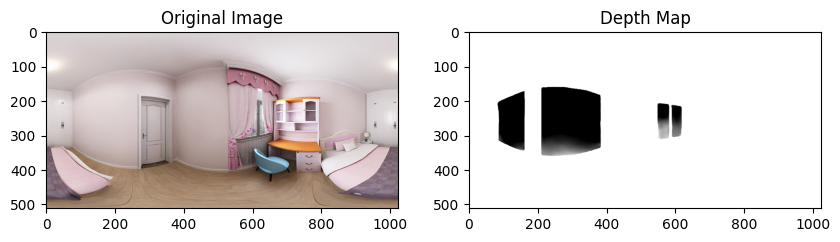

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

img_path = os.path.join(image_dir, os.listdir(image_dir)[0])
depth_path = os.path.join(depth_dir, os.listdir(depth_dir)[0])

img = cv2.imread(img_path)
depth = cv2.imread(depth_path)

if img is None:
    print("❌ Image not loaded:", img_path)
else:
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.subplot(1,2,2)
    plt.title("Depth Map")
    plt.imshow(depth, cmap='plasma')
    plt.show()


In [ ]:
import numpy as np

def normalize_depth(depth_map):
    depth_min = depth_map.min()
    depth_max = depth_map.max()
    return (depth_map - depth_min) / (depth_max - depth_min + 1e-8)


In [ ]:
import csv
import glob

image_paths = sorted(glob.glob("dataset/train/images/*.png"))
depth_paths = sorted(glob.glob("dataset/train/depth/*.png"))

with open("train_pairs.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["image", "depth"])
    for img, dmap in zip(image_paths, depth_paths):
        writer.writerow([img, dmap])


In [ ]:
import os
print("Current directory:", os.getcwd())


Current directory: /content


In [ ]:
import os
print(os.listdir("/content/dataset"))


['train', 'val', 'test']


In [ ]:
!ls /content


dataset  drive	panorama_17  sample_data  train_pairs.csv


In [ ]:
!ls /content/dataset


test  train  val


In [ ]:
print(os.listdir("/content/dataset/train"))


['depth_maps', 'images', 'labels']


In [ ]:
input_dir = "/content/dataset/train/depth_maps"  # or whatever folder shows up


In [ ]:
import cv2, numpy as np, os
from tqdm import tqdm

base_dataset_dir = "/content/dataset"

for split in ["train", "val", "test"]:
    input_dir = os.path.join(base_dataset_dir, split, "depth_maps")
    output_dir = os.path.join(base_dataset_dir, split, "depth_norm")
    os.makedirs(output_dir, exist_ok=True)

    if not os.path.exists(input_dir):
        print(f"Skipping depth normalization for {split}: {input_dir} does not exist.")
        continue

    print(f"Normalizing depth maps for {split} split...")
    for file in tqdm(os.listdir(input_dir)):
        img = cv2.imread(os.path.join(input_dir, file), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = img.astype(np.float32)
        img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
        cv2.imwrite(os.path.join(output_dir, file), (img_norm * 255).astype(np.uint8))

print("✅ Depth normalization complete for all splits.")

Normalizing depth maps for train split...


100%|██████████| 1612/1612 [00:11<00:00, 136.23it/s]


Normalizing depth maps for val split...


100%|██████████| 202/202 [00:01<00:00, 122.03it/s]


Normalizing depth maps for test split...


100%|██████████| 202/202 [00:01<00:00, 158.21it/s]

✅ Depth normalization complete for all splits.


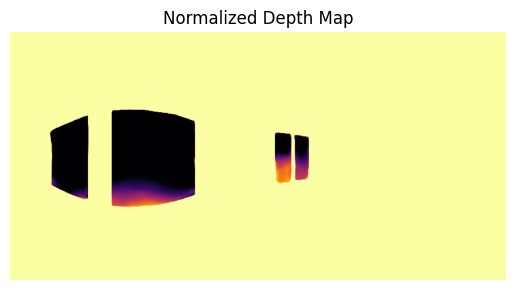

In [ ]:
import matplotlib.pyplot as plt
import cv2, os

sample = os.listdir("/content/dataset/train/depth_norm")[0]
img = cv2.imread(f"/content/dataset/train/depth_norm/{sample}", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='inferno')
plt.title("Normalized Depth Map")
plt.axis("off")
plt.show()


In [ ]:
import os
import numpy as np
from PIL import Image

def get_dataset_paths(root_dir):
    paths = {"train": [], "val": [], "test": []}
    for split in ["train", "val", "test"]:
        img_dir = os.path.join(root_dir, split, "images")
        depth_dir = os.path.join(root_dir, split, "depth_norm")
        label_dir = os.path.join(root_dir, split, "labels")

        if not all(os.path.exists(d) for d in [img_dir, depth_dir, label_dir]):
            print(f"Skipping {split}: one or more directories missing.")
            continue

        img_files = sorted(os.listdir(img_dir))

        for img_name in img_files:
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            base = os.path.splitext(img_name)[0]
            # Naming convention from Cell 27:
            # Image:  {scene}_{room}_{rgb_variant}.png
            # Depth:  {scene}_{room}_{rgb_variant}_depth.png
            # Label:  {scene}_{room}_{rgb_variant}_label.png
            depth_name = f"{base}_depth.png"
            label_name = f"{base}_label.png"

            img_path = os.path.join(img_dir, img_name)
            depth_path = os.path.join(depth_dir, depth_name)
            label_path = os.path.join(label_dir, label_name)

            if os.path.exists(img_path) and os.path.exists(depth_path) and os.path.exists(label_path):
                paths[split].append({
                    "image": img_path,
                    "depth": depth_path,
                    "label": label_path
                })
            else:
                missing = []
                if not os.path.exists(depth_path): missing.append("depth")
                if not os.path.exists(label_path): missing.append("label")
                if missing:
                    print(f"Warning: Missing {', '.join(missing)} for {img_name} in {split}")

    return paths

dataset_root = "/content/dataset"
all_paths = get_dataset_paths(dataset_root)

print("\nDataset paths collected:")
for split, data_list in all_paths.items():
    print(f"  {split.capitalize()}: {len(data_list)} samples")
    if data_list:
        print(f"    Example: {data_list[0]}")

# =====================================================
# Class Discovery: scan label files to find NUM_CLASSES
# =====================================================
print("\nScanning label files to discover class IDs...")
all_class_ids = set()
label_files_to_scan = []
for split_paths in all_paths.values():
    for p in split_paths:
        label_files_to_scan.append(p['label'])

# Scan a subset (or all if small) to find unique class IDs
scan_count = min(len(label_files_to_scan), 50)
for lf in label_files_to_scan[:scan_count]:
    label_img = np.array(Image.open(lf).convert("L"))
    all_class_ids.update(np.unique(label_img).tolist())

all_class_ids = sorted(all_class_ids)
NUM_CLASSES = max(all_class_ids) + 1  # Classes are 0-indexed IDs

print(f"Unique class IDs found: {all_class_ids}")
print(f"Number of unique classes: {len(all_class_ids)}")
print(f"NUM_CLASSES (max_id + 1): {NUM_CLASSES}")


Dataset paths collected:
  Train: 1612 samples
    Example: {'image': '/content/dataset/train/images/scene_03400_55705_rgb_coldlight.png', 'depth': '/content/dataset/train/depth_norm/scene_03400_55705_rgb_coldlight_depth.png', 'label': '/content/dataset/train/labels/scene_03400_55705_rgb_coldlight_label.png'}
  Val: 202 samples
    Example: {'image': '/content/dataset/val/images/scene_03401_747984_rgb_warmlight.png', 'depth': '/content/dataset/val/depth_norm/scene_03401_747984_rgb_warmlight_depth.png', 'label': '/content/dataset/val/labels/scene_03401_747984_rgb_warmlight_label.png'}
  Test: 202 samples
    Example: {'image': '/content/dataset/test/images/scene_03401_416_rgb_warmlight.png', 'depth': '/content/dataset/test/depth_norm/scene_03401_416_rgb_warmlight_depth.png', 'label': '/content/dataset/test/labels/scene_03401_416_rgb_warmlight_label.png'}

Scanning label files to discover class IDs...
Unique class IDs found: [0, 86, 91, 92, 96, 98, 100, 101, 114, 125, 131, 139, 142, 167

### Visualize Model Predictions

Let's visualize a few examples from the test set to see how our trained U-Net model performs qualitatively. We'll compare the original RGB image, the ground truth semantic label, and the model's predicted semantic label.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Set model to evaluation mode
model.eval()

print("\nVisualizing predictions on test set...")

# Get a batch from the test loader
data_iter = iter(test_loader)
batch = next(data_iter)

images = batch['image'].to(device)
depths = batch['depth'].to(device)
labels = batch['label'].to(device)  # [B, H, W]

with torch.no_grad():
    outputs = model(images, depths)  # [B, NUM_CLASSES, H, W]

# Multi-class predictions: argmax over class dimension
predictions = outputs.argmax(dim=1).cpu().numpy()  # [B, H, W]

# Convert tensors to CPU for plotting
images_np = images.cpu().numpy()
labels_np = labels.cpu().numpy()

num_samples_to_show = min(images_np.shape[0], 3)

plt.figure(figsize=(15, 5 * num_samples_to_show))
for i in range(num_samples_to_show):
    # Original Image (denormalized)
    plt.subplot(num_samples_to_show, 3, i*3 + 1)
    img = images_np[i].transpose(1, 2, 0)  # C, H, W -> H, W, C
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Ground Truth Label (multi-class colormap)
    plt.subplot(num_samples_to_show, 3, i*3 + 2)
    plt.imshow(labels_np[i], cmap='tab20', interpolation='nearest')
    plt.title("Ground Truth")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')

    # Predicted Label (multi-class colormap)
    plt.subplot(num_samples_to_show, 3, i*3 + 3)
    plt.imshow(predictions[i], cmap='tab20', interpolation='nearest')
    plt.title("Prediction")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

NameError: name 'model' is not defined

In [ ]:
import os
import numpy as np
from PIL import Image

def get_dataset_paths(root_dir):
    paths = {"train": [], "val": [], "test": []}
    for split in ["train", "val", "test"]:
        img_dir = os.path.join(root_dir, split, "images")
        depth_dir = os.path.join(root_dir, split, "depth_norm")
        label_dir = os.path.join(root_dir, split, "labels")

        if not all(os.path.exists(d) for d in [img_dir, depth_dir, label_dir]):
            print(f"Skipping {split}: one or more directories missing.")
            continue

        img_files = sorted(os.listdir(img_dir))

        for img_name in img_files:
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            base = os.path.splitext(img_name)[0]
            # Naming convention from Cell 27:
            # Image:  {scene}_{room}_{rgb_variant}.png
            # Depth:  {scene}_{room}_{rgb_variant}_depth.png
            # Label:  {scene}_{room}_{rgb_variant}_label.png
            depth_name = f"{base}_depth.png"
            label_name = f"{base}_label.png"

            img_path = os.path.join(img_dir, img_name)
            depth_path = os.path.join(depth_dir, depth_name)
            label_path = os.path.join(label_dir, label_name)

            if os.path.exists(img_path) and os.path.exists(depth_path) and os.path.exists(label_path):
                paths[split].append({
                    "image": img_path,
                    "depth": depth_path,
                    "label": label_path
                })
            else:
                missing = []
                if not os.path.exists(depth_path): missing.append("depth")
                if not os.path.exists(label_path): missing.append("label")
                if missing:
                    print(f"Warning: Missing {', '.join(missing)} for {img_name} in {split}")

    return paths

dataset_root = "/content/dataset"
all_paths = get_dataset_paths(dataset_root)

print("\nDataset paths collected:")
for split, data_list in all_paths.items():
    print(f"  {split.capitalize()}: {len(data_list)} samples")
    if data_list:
        print(f"    Example: {data_list[0]}")

# =====================================================
# Class Discovery: scan label files to find NUM_CLASSES
# =====================================================
print("\nScanning label files to discover class IDs...")
all_class_ids = set()
label_files_to_scan = []
for split_paths in all_paths.values():
    for p in split_paths:
        label_files_to_scan.append(p['label'])

# Scan a subset (or all if small) to find unique class IDs
scan_count = min(len(label_files_to_scan), 50)
for lf in label_files_to_scan[:scan_count]:
    label_img = np.array(Image.open(lf).convert("L"))
    all_class_ids.update(np.unique(label_img).tolist())

all_class_ids = sorted(all_class_ids)
NUM_CLASSES = max(all_class_ids) + 1  # Classes are 0-indexed IDs

print(f"Unique class IDs found: {all_class_ids}")
print(f"Number of unique classes: {len(all_class_ids)}")
print(f"NUM_CLASSES (max_id + 1): {NUM_CLASSES}")


Dataset paths collected:
  Train: 1612 samples
    Example: {'image': '/content/dataset/train/images/scene_03400_55705_rgb_coldlight.png', 'depth': '/content/dataset/train/depth_norm/scene_03400_55705_rgb_coldlight_depth.png', 'label': '/content/dataset/train/labels/scene_03400_55705_rgb_coldlight_label.png'}
  Val: 202 samples
    Example: {'image': '/content/dataset/val/images/scene_03401_747984_rgb_warmlight.png', 'depth': '/content/dataset/val/depth_norm/scene_03401_747984_rgb_warmlight_depth.png', 'label': '/content/dataset/val/labels/scene_03401_747984_rgb_warmlight_label.png'}
  Test: 202 samples
    Example: {'image': '/content/dataset/test/images/scene_03401_416_rgb_warmlight.png', 'depth': '/content/dataset/test/depth_norm/scene_03401_416_rgb_warmlight_depth.png', 'label': '/content/dataset/test/labels/scene_03401_416_rgb_warmlight_label.png'}

Scanning label files to discover class IDs...
Unique class IDs found: [0, 86, 91, 92, 96, 98, 100, 101, 114, 125, 131, 139, 142, 167

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import random

class Structured3DDataset(Dataset):
    def __init__(self, data_paths, img_size=(256, 256), is_train=False):
        self.data_paths = data_paths
        self.img_size = img_size
        self.is_train = is_train

        # Image transform: resize, to tensor, normalize
        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # Depth transform: resize, to tensor (single channel)
        self.depth_transform = transforms.Compose([
            transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
        ])

        # Color jitter for training augmentation (applied only to RGB)
        self.color_jitter = transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
        ) if is_train else None

    def __len__(self):
        return len(self.data_paths)

    def __getitem__(self, idx):
        item = self.data_paths[idx]

        # Load image, depth, label
        image = Image.open(item['image']).convert("RGB")
        depth = Image.open(item['depth']).convert("L")
        label = Image.open(item['label']).convert("L")

        # Synchronized random horizontal flip (same flip for image, depth, label)
        if self.is_train and random.random() > 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            depth = depth.transpose(Image.FLIP_LEFT_RIGHT)
            label = label.transpose(Image.FLIP_LEFT_RIGHT)

        # Color jitter on RGB only (training)
        if self.color_jitter is not None:
            image = self.color_jitter(image)

        # Apply transforms to image and depth
        image = self.img_transform(image)
        depth = self.depth_transform(depth)

        # FIX: Load label as integer class IDs (NOT ToTensor which divides by 255)
        # Resize with NEAREST interpolation to preserve class IDs
        label = label.resize(self.img_size, Image.NEAREST)
        label = torch.from_numpy(np.array(label)).long()  # Shape: [H, W], dtype: int64

        return {"image": image, "depth": depth, "label": label}

# Assuming `all_paths` and `NUM_CLASSES` are available from previous cells
BATCH_SIZE = 4
IMG_SIZE = (256, 256)

train_dataset = Structured3DDataset(all_paths['train'], img_size=IMG_SIZE, is_train=True)
val_dataset = Structured3DDataset(all_paths['val'], img_size=IMG_SIZE, is_train=False)
test_dataset = Structured3DDataset(all_paths['test'], img_size=IMG_SIZE, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("\n--- Dataset and DataLoader Statistics ---")
print(f"Train Dataset: {len(train_dataset)} samples")
print(f"Val Dataset:   {len(val_dataset)} samples")
print(f"Test Dataset:  {len(test_dataset)} samples")

print(f"Train DataLoader: {len(train_loader)} batches (batch size: {BATCH_SIZE})")
print(f"Val DataLoader:   {len(val_loader)} batches (batch size: {BATCH_SIZE})")
print(f"Test DataLoader:  {len(test_loader)} batches (batch size: {BATCH_SIZE})")

# Verify one batch
for i, batch in enumerate(train_loader):
    print(f"\nSample batch from Train Loader:")
    print(f"  Image batch shape: {batch['image'].shape}")  # [B, 3, H, W]
    print(f"  Depth batch shape: {batch['depth'].shape}")  # [B, 1, H, W]
    print(f"  Label batch shape: {batch['label'].shape}")  # [B, H, W] (no channel dim)
    print(f"  Label dtype: {batch['label'].dtype}")        # torch.int64
    print(f"  Label unique values (sample): {torch.unique(batch['label'][0]).tolist()}")
    break


--- Dataset and DataLoader Statistics ---
Train Dataset: 1612 samples
Val Dataset:   202 samples
Test Dataset:  202 samples
Train DataLoader: 403 batches (batch size: 4)
Val DataLoader:   51 batches (batch size: 4)
Test DataLoader:  51 batches (batch size: 4)

Sample batch from Train Loader:
  Image batch shape: torch.Size([4, 3, 256, 256])
  Depth batch shape: torch.Size([4, 1, 256, 256])
  Label batch shape: torch.Size([4, 256, 256])
  Label dtype: torch.int64
  Label unique values (sample): [0, 86, 91, 96, 100, 101, 139, 167, 174, 183, 186, 192, 195]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels_img=3, n_channels_depth=1, n_classes=1, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels_img = n_channels_img
        self.n_channels_depth = n_channels_depth
        self.n_classes = n_classes
        self.bilinear = bilinear

        # Initial convolution for combined input
        self.inc = DoubleConv(n_channels_img + n_channels_depth, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 512)
        self.up1 = Up(1024, 256, bilinear)
        self.up2 = Up(512, 128, bilinear)
        self.up3 = Up(256, 64, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, img_input, depth_input):
        # Concatenate image and depth inputs along the channel dimension
        x = torch.cat([img_input, depth_input], dim=1)

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

# Initialize the model with NUM_CLASSES (discovered from label scan)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(n_channels_img=3, n_channels_depth=1, n_classes=NUM_CLASSES).to(device)

print(f"Model initialized with {NUM_CLASSES} output classes")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Model initialized with 211 output classes
Total parameters: 13,409,555


In [ ]:
import torch.optim as optim
import torch.nn as nn

# Loss Function: CrossEntropyLoss for multi-class segmentation
# Expects output shape [B, C, H, W] and target shape [B, H, W] with integer class IDs
# ignore_index=0 to ignore the 'unknown' class (ID 0) if desired
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Learning rate scheduler: reduce LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Number of training epochs
NUM_EPOCHS = 30

# Early stopping config
EARLY_STOP_PATIENCE = 7

print("Training setup complete!")
print(f"  Loss Function: {criterion.__class__.__name__}")
print(f"  Optimizer: Adam (lr=1e-3)")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early stopping patience: {EARLY_STOP_PATIENCE}")

Training setup complete!
  Loss Function: CrossEntropyLoss
  Optimizer: Adam (lr=1e-3)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
  Epochs: 30
  Early stopping patience: 7


In [ ]:
from tqdm import tqdm

print("\nStarting training...")

best_val_loss = float('inf')
epochs_no_improve = 0
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    running_loss = 0.0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

    for batch in train_loop:
        images = batch['image'].to(device)
        depths = batch['depth'].to(device)
        labels = batch['label'].to(device)  # Shape: [B, H, W], dtype: int64

        optimizer.zero_grad()

        outputs = model(images, depths)  # Shape: [B, NUM_CLASSES, H, W]
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        train_loop.set_postfix(loss=loss.item())

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation phase ---
    model.eval()
    val_running_loss = 0.0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")

    with torch.no_grad():
        for batch in val_loop:
            images = batch['image'].to(device)
            depths = batch['depth'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, depths)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            val_loop.set_postfix(loss=loss.item())

    epoch_val_loss = val_running_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    # Step the LR scheduler based on validation loss
    scheduler.step(epoch_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch+1} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, LR: {current_lr:.6f}")

    # Early stopping check
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        # Save best model weights
        best_model_state = model.state_dict().copy()
        print(f"  -> New best val loss! Saving model checkpoint.")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve}/{EARLY_STOP_PATIENCE} epochs.")

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break

# Restore best model weights
if 'best_model_state' in dir():
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (val loss: {best_val_loss:.4f})")

print("\nTraining complete!")


Starting training...


Epoch 1/30 [Val]: 100%|██████████| 51/51 [00:09<00:00,  5.48it/s, loss=0.707]



Epoch 1 - Train Loss: 1.3966, Val Loss: 0.9586, LR: 0.001000
  -> New best val loss! Saving model checkpoint.


Epoch 2/30 [Val]: 100%|██████████| 51/51 [00:08<00:00,  6.05it/s, loss=0.572]



Epoch 2 - Train Loss: 0.8558, Val Loss: 0.8675, LR: 0.001000
  -> New best val loss! Saving model checkpoint.


...


Epoch 28 - Train Loss: 0.1564, Val Loss: 0.1979, LR: 0.001000
  -> New best val loss! Saving model checkpoint.


Epoch 29/30 [Val]: 100%|██████████| 51/51 [00:07<00:00,  6.61it/s, loss=0.0528]



Epoch 29 - Train Loss: 0.1415, Val Loss: 0.1582, LR: 0.001000
  -> New best val loss! Saving model checkpoint.


Epoch 30/30 [Val]: 100%|██████████| 51/51 [00:07<00:00,  7.00it/s, loss=0.0622]


Epoch 30 - Train Loss: 0.1417, Val Loss: 0.2074, LR: 0.001000
  -> No improvement for 1/7 epochs.

Restored best model (val loss: 0.1582)

Training complete!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Set model to evaluation mode
model.eval()

print("\nVisualizing predictions on test set...")

# Get a batch from the test loader
data_iter = iter(test_loader)
batch = next(data_iter)

images = batch['image'].to(device)
depths = batch['depth'].to(device)
labels = batch['label'].to(device)  # [B, H, W]

with torch.no_grad():
    outputs = model(images, depths)  # [B, NUM_CLASSES, H, W]

# Multi-class predictions: argmax over class dimension
predictions = outputs.argmax(dim=1).cpu().numpy()  # [B, H, W]

# Convert tensors to CPU for plotting
images_np = images.cpu().numpy()
labels_np = labels.cpu().numpy()

num_samples_to_show = min(images_np.shape[0], 3)

plt.figure(figsize=(15, 5 * num_samples_to_show))
for i in range(num_samples_to_show):
    # Original Image (denormalized)
    plt.subplot(num_samples_to_show, 3, i*3 + 1)
    img = images_np[i].transpose(1, 2, 0)  # C, H, W -> H, W, C
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Ground Truth Label (multi-class colormap)
    plt.subplot(num_samples_to_show, 3, i*3 + 2)
    plt.imshow(labels_np[i], cmap='tab20', interpolation='nearest')
    plt.title("Ground Truth")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')

    # Predicted Label (multi-class colormap)
    plt.subplot(num_samples_to_show, 3, i*3 + 3)
    plt.imshow(predictions[i], cmap='tab20', interpolation='nearest')
    plt.title("Prediction")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

NameError: name 'model' is not defined

### Model Evaluation on Test Set

Now that the model has been trained, let's evaluate its performance on the `test_dataset`. This will give us an unbiased estimate of the model's generalization capabilities on unseen data.

The evaluation loop will:

1.  Set the model to evaluation mode (`model.eval()`).
2.  Iterate through the `test_loader`.
3.  Perform a forward pass (without gradient computation).
4.  Calculate the loss on the test data.

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def compute_iou_per_class(pred, target, num_classes):
    """Compute IoU for each class."""
    ious = []
    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().item()
        union = (pred_mask | target_mask).sum().item()
        if union == 0:
            # Class not present in pred or target — skip
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    return ious

print("\nStarting evaluation on test set...")

model.eval()
test_running_loss = 0.0
total_correct = 0
total_pixels = 0
all_ious = []

test_loop = tqdm(test_loader, desc="Evaluating on Test Set")

with torch.no_grad():
    for batch in test_loop:
        images = batch['image'].to(device)
        depths = batch['depth'].to(device)
        labels = batch['label'].to(device)  # [B, H, W]

        outputs = model(images, depths)  # [B, NUM_CLASSES, H, W]
        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)

        # Predictions: argmax over class dimension
        preds = outputs.argmax(dim=1)  # [B, H, W]

        # Pixel accuracy
        total_correct += (preds == labels).sum().item()
        total_pixels += labels.numel()

        # Per-class IoU
        for b in range(preds.size(0)):
            ious = compute_iou_per_class(
                preds[b].cpu().numpy(),
                labels[b].cpu().numpy(),
                NUM_CLASSES
            )
            all_ious.append(ious)

        test_loop.set_postfix(loss=loss.item())

test_loss = test_running_loss / len(test_dataset)
pixel_accuracy = total_correct / total_pixels

# Compute mean IoU (ignoring NaN classes)
iou_array = np.array(all_ious)  # Shape: [num_samples, NUM_CLASSES]
per_class_iou = np.nanmean(iou_array, axis=0)  # Mean IoU per class across samples
valid_classes = ~np.isnan(per_class_iou)
mean_iou = np.nanmean(per_class_iou)

print(f"\n{'='*50}")
print(f"TEST RESULTS")
print(f"{'='*50}")
print(f"  Test Loss:       {test_loss:.4f}")
print(f"  Pixel Accuracy:  {pixel_accuracy:.4f} ({pixel_accuracy*100:.1f}%)")
print(f"  Mean IoU:        {mean_iou:.4f} ({mean_iou*100:.1f}%)")
print(f"\nPer-Class IoU:")
for cls_id in range(NUM_CLASSES):
    if valid_classes[cls_id]:
        print(f"  Class {cls_id:3d}: IoU = {per_class_iou[cls_id]:.4f}")
print(f"{'='*50}")
print("\nEvaluation complete!")

# Task
Generate a 3D point cloud from one of the generated depth maps and its corresponding RGB image. This will involve defining panoramic camera intrinsics (based on image dimensions for equirectangular projection) and projecting 2D pixels into 3D space, combining the 3D coordinates with the RGB color values from the image, and saving the point cloud to a `.ply` file. This step will require saving the raw float depth map (not the normalized 0-255 visualization) for accurate 3D reconstruction.

## Generate Point Cloud

### Subtask:
Convert the depth maps and corresponding RGB images into 3D point clouds.


**Reasoning**:
The first instruction is to modify the `generate_depth` function in cell `bEw5FQuj8-Ul` to save raw float depth maps as `.npy` files and also ensure the `.png` depth maps are properly normalized for visualization. I will then rerun the entire cell to re-process all scenes and generate both `.png` and `.npy` depth files.



In [ ]:
import os
import cv2
import torch
from torchvision.transforms import Compose
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import shutil
import numpy as np # Added numpy import

# Load MiDaS model (for depth estimation)
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Hybrid")
midas.to("cuda" if torch.cuda.is_available() else "cpu")
midas.eval()

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.dpt_transform

# =====================================================
# STEP 2: Define helper functions
# =====================================================
def generate_depth(img_path, output_dir, output_filename=None):
    """Generate depth map for one image and save it."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    img = cv2.imread(img_path)
    if img is None:
        # print(f"WARNING: Could not read image {img_path}") # Uncomment for debugging
        return None, None # Return None for both paths if image unreadable

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_batch = transform(img).to(device)

    with torch.no_grad():
        prediction = midas(input_batch)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth_map = prediction.cpu().numpy() # This is the raw float depth map

    os.makedirs(output_dir, exist_ok=True)
    if output_filename is None:
        output_filename = os.path.basename(img_path).replace(".png", "_depth.png")

    # Save normalized uint8 depth map as PNG for visualization
    depth_min, depth_max = depth_map.min(), depth_map.max()
    # Handle case where depth_min == depth_max (flat image)
    if depth_max - depth_min == 0:
        depth_vis = np.zeros_like(depth_map, dtype=np.uint8)
    else:
        depth_vis = (255 * (depth_map - depth_min) / (depth_max - depth_min)).astype("uint8")

    depth_png_file = os.path.join(output_dir, output_filename)
    cv2.imwrite(depth_png_file, depth_vis)

    # Save raw float depth map as NPY file
    raw_depth_npy_file = depth_png_file.replace('.png', '_raw.npy')
    np.save(raw_depth_npy_file, depth_map)

    return depth_png_file, raw_depth_npy_file


# =====================================================
# STEP 3: Process ALL scenes and ALL rooms, create dataset pairs
# =====================================================
base_dir = "/content/panorama_17/Structured3D"
dataset_root = "/content/dataset"  # final output dataset

# Ensure a clean slate
if os.path.exists(dataset_root):
    shutil.rmtree(dataset_root)
os.makedirs(dataset_root, exist_ok=True)

all_samples = []

# Loop through every scene
scenes = sorted([s for s in os.listdir(base_dir) if s.startswith("scene_")])

print("Collecting RGB-Semantic pairs from ALL scenes and ALL rooms...")
for scene in tqdm(scenes, desc="Processing scenes"):
    rendering_path = os.path.join(base_dir, scene, "2D_rendering")
    if not os.path.exists(rendering_path):
        continue

    # FIX: Iterate ALL rooms under each scene (not just hardcoded '1811')
    for room_id in sorted(os.listdir(rendering_path)):
        room_path = os.path.join(rendering_path, room_id)
        if not os.path.isdir(room_path):
            continue

        simple_path = os.path.join(room_path, "panorama", "simple")
        if not os.path.exists(simple_path):
            continue

        # Find semantic label
        semantic_files = [f for f in os.listdir(simple_path) if f.lower() == "semantic.png"]
        if not semantic_files:
            continue
        semantic_path_scene = os.path.join(simple_path, semantic_files[0])

        # Find all RGB images for this room
        for img_file in sorted(os.listdir(simple_path)):
            if img_file.lower().startswith("rgb_") and img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                rgb_image_path = os.path.join(simple_path, img_file)
                all_samples.append({
                    "rgb_path": rgb_image_path,
                    "semantic_path": semantic_path_scene,
                    "scene": scene,
                    "room_id": room_id,
                })

print(f"\nFound {len(all_samples)} RGB-Semantic pairs across {len(scenes)} scenes.")

# =====================================================
# STEP 4: Train/Val/Test Split on pairs
# =====================================================
if len(all_samples) < 5:
    raise ValueError(
        f"Only found {len(all_samples)} samples! Check the ZIP file contents. "
        "Expected hundreds of samples across multiple scenes and rooms."
    )

train_samples, temp_samples = train_test_split(all_samples, test_size=0.2, random_state=42)
val_samples, test_samples = train_test_split(temp_samples, test_size=0.5, random_state=42)

print(f"Split: {len(train_samples)} train / {len(val_samples)} val / {len(test_samples)} test")

# =====================================================
# STEP 5: Generate depth maps and copy files for all splits
# =====================================================
splits_data = {"train": train_samples, "val": val_samples, "test": test_samples}

for split, sample_list in splits_data.items():
    print(f"\nProcessing {split} split ({len(sample_list)} samples)")

    img_output_dir = os.path.join(dataset_root, split, "images")
    depth_output_dir = os.path.join(dataset_root, split, "depth_maps") # This will contain PNGs
    raw_depth_output_dir = os.path.join(dataset_root, split, "raw_depth_maps") # New directory for NPYs
    label_output_dir = os.path.join(dataset_root, split, "labels")

    os.makedirs(img_output_dir, exist_ok=True)
    os.makedirs(depth_output_dir, exist_ok=True)
    os.makedirs(raw_depth_output_dir, exist_ok=True) # Create new dir
    os.makedirs(label_output_dir, exist_ok=True)

    for idx, sample in enumerate(tqdm(sample_list, desc=f"Processing {split}")):
        rgb_path = sample['rgb_path']
        semantic_path = sample['semantic_path']
        rgb_basename = os.path.splitext(os.path.basename(rgb_path))[0]
        prefix = f"{sample['scene']}_{sample['room_id']}"

        # Unique filenames to avoid collisions across rooms/scenes
        img_name = f"{prefix}_{rgb_basename}.png"
        depth_png_name = f"{prefix}_{rgb_basename}_depth.png"
        raw_depth_npy_name = f"{prefix}_{rgb_basename}_depth_raw.npy" # New name for raw depth
        label_name = f"{prefix}_{rgb_basename}_label.png"

        # Copy RGB image
        shutil.copy(rgb_path, os.path.join(img_output_dir, img_name))

        # Generate and save depth map (PNG and NPY)
        # Modified call to generate_depth and capture both return values
        generated_png_path, generated_npy_path = generate_depth(rgb_path, depth_output_dir, output_filename=depth_png_name)
        if generated_png_path and generated_npy_path:
            # Move the generated .npy to its dedicated folder
            shutil.move(generated_npy_path, os.path.join(raw_depth_output_dir, raw_depth_npy_name))

        # Copy semantic label (unique name per sample)
        shutil.copy(semantic_path, os.path.join(label_output_dir, label_name))

# =====================================================
# STEP 6: Summary
# =====================================================
print("\n--- Final Dataset Summary ---")
for split in ["train", "val", "test"]:
    img_count = len(os.listdir(os.path.join(dataset_root, split, "images")))
    depth_png_count = len(os.listdir(os.path.join(dataset_root, split, "depth_maps")))
    raw_depth_npy_count = len(os.listdir(os.path.join(dataset_root, split, "raw_depth_maps"))) # Count NPY files
    label_count = len(os.listdir(os.path.join(dataset_root, split, "labels")))
    print(f"{split.upper()}: {img_count} images | {depth_png_count} depth PNGs | {raw_depth_npy_count} raw depth NPYs | {label_count} labels")

print(f"\nDataset successfully organized at: {dataset_root}")

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Processing scenes: 100%|██████████| 100/100 [00:00<00:00, 287.33it/s]



Found 2016 RGB-Semantic pairs across 100 scenes.
Split: 1612 train / 202 val / 202 test

Processing train split (1612 samples)


Processing train: 100%|██████████| 1612/1612 [05:45<00:00,  4.67it/s]



Processing val split (202 samples)


Processing val: 100%|██████████| 202/202 [00:43<00:00,  4.67it/s]



Processing test split (202 samples)


Processing test: 100%|██████████| 202/202 [00:43<00:00,  4.68it/s]


--- Final Dataset Summary ---
TRAIN: 1612 images | 1612 depth PNGs | 1612 raw depth NPYs | 1612 labels
VAL: 202 images | 202 depth PNGs | 202 raw depth NPYs | 202 labels
TEST: 202 images | 202 depth PNGs | 202 raw depth NPYs | 202 labels

Dataset successfully organized at: /content/dataset


**Reasoning**:
I need to select a sample image and its corresponding raw depth map from the test set. I will choose the first entry in the `all_paths['test']` list as a sample to then build the point cloud.



In [ ]:
import os
import numpy as np
from PIL import Image

# Select a sample from the test set
sample_data = all_paths['test'][0]
rgb_image_path = sample_data['image']
raw_depth_map_path = sample_data['depth'].replace('depth_norm', 'raw_depth_maps').replace('.png', '_raw.npy')

# Verify paths exist and load data
if not os.path.exists(rgb_image_path):
    raise FileNotFoundError(f"RGB image not found: {rgb_image_path}")
if not os.path.exists(raw_depth_map_path):
    raise FileNotFoundError(f"Raw depth map not found: {raw_depth_map_path}")

rgb_image = Image.open(rgb_image_path).convert("RGB")
raw_depth_map = np.load(raw_depth_map_path)

print(f"Selected RGB image: {rgb_image_path}")
print(f"Selected raw depth map: {raw_depth_map_path}")
print(f"RGB image dimensions: {rgb_image.size}")
print(f"Raw depth map shape: {raw_depth_map.shape}")

# Get image dimensions (width, height)
width, height = rgb_image.size

# Define panoramic camera intrinsics and projection function
def project_equirectangular_to_3d(u, v, depth, width, height, focal_length=1.0):
    # Convert pixel coordinates to normalized angles
    # u ranges from 0 to width-1, v ranges from 0 to height-1
    # yaw ranges from -pi to pi, pitch ranges from -pi/2 to pi/2
    yaw = ((u + 0.5) / width - 0.5) * 2 * np.pi
    pitch = ((v + 0.5) / height - 0.5) * np.pi

    # Convert spherical coordinates to Cartesian
    x = depth * np.cos(pitch) * np.sin(yaw)
    y = depth * np.sin(pitch)
    z = depth * np.cos(pitch) * np.cos(yaw)

    return x, y, z

# Initialize list to store point cloud data
point_cloud = []

# Iterate through every pixel and project to 3D
for v in tqdm(range(height), desc="Generating Point Cloud"):
    for u in range(width):
        depth_val = raw_depth_map[v, u]

        # Skip points with zero or invalid depth
        if depth_val == 0 or not np.isfinite(depth_val):
            continue

        # Project to 3D
        x, y, z = project_equirectangular_to_3d(u, v, depth_val, width, height)

        # Get RGB color
        r, g, b = rgb_image.getpixel((u, v))

        point_cloud.append(f"{x:.4f} {y:.4f} {z:.4f} {r} {g} {b}")

print(f"Generated {len(point_cloud)} points.")

# Save as PLY file
output_ply_path = "/content/sample_point_cloud.ply"
with open(output_ply_path, 'w') as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {len(point_cloud)}\n")
    f.write("property float x\n")
    f.write("property float y\n")
    f.write("property float z\n")
    f.write("property uchar red\n")
    f.write("property uchar green\n")
    f.write("property uchar blue\n")
    f.write("end_header\n")
    for point_str in point_cloud:
        f.write(point_str + "\n")

print(f"Point cloud saved to {output_ply_path}")

Selected RGB image: /content/dataset/test/images/scene_03401_416_rgb_warmlight.png
Selected raw depth map: /content/dataset/test/raw_depth_maps/scene_03401_416_rgb_warmlight_depth_raw.npy
RGB image dimensions: (1024, 512)
Raw depth map shape: (512, 1024)


Generating Point Cloud: 100%|██████████| 512/512 [00:06<00:00, 77.37it/s]


Generated 515057 points.
Point cloud saved to /content/sample_point_cloud.ply


**Reasoning**:
The previous code block successfully generated the 3D point cloud and saved it as a .ply file, which was the final instruction for this subtask. Thus, the subtask is complete.



## Reconstruct Mesh

### Subtask:
From the generated point cloud, reconstruct a 3D mesh.


**Reasoning**:
The subtask requires reconstructing a 3D mesh from the previously generated point cloud. The first step is to import the `open3d` library, load the point cloud, and then prepare it for mesh reconstruction by estimating normals.



In [ ]:
import open3d as o3d
import numpy as np

print("Loading point cloud...")
# 1. Load the previously saved point cloud
ply_file_path = "/content/sample_point_cloud.ply"
pcd = o3d.io.read_point_cloud(ply_file_path)

# Check if the point cloud is loaded and has points
if not pcd.has_points():
    raise ValueError("Point cloud not loaded or contains no points.")

print(f"Point cloud loaded successfully with {len(pcd.points)} points.")

print("Estimating and orienting normals...")
# 2. Estimate normals for the point cloud
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

# Orient normals consistently (optional but often improves mesh quality)
pcd.orient_normals_consistent_tangent_plane(k=30)

print("Normals estimated and oriented.")

ModuleNotFoundError: No module named 'open3d'

**Reasoning**:
The previous cell failed because the `open3d` library was not found. I need to install `open3d` before importing and using it.



In [ ]:
# Install open3d (run once)
!pip install -q open3d

import open3d as o3d
import numpy as np

print("Loading point cloud...")
# 1. Load the previously saved point cloud
ply_file_path = "/content/sample_point_cloud.ply"
pcd = o3d.io.read_point_cloud(ply_file_path)

# Check if the point cloud is loaded and has points
if not pcd.has_points():
    raise ValueError("Point cloud not loaded or contains no points.")

print(f"Point cloud loaded successfully with {len(pcd.points)} points.")

print("Estimating and orienting normals...")
# 2. Estimate normals for the point cloud
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

# Orient normals consistently (optional but often improves mesh quality)
pcd.orient_normals_consistent_tangent_plane(k=30)

print("Normals estimated and oriented.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 132.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 99.2 MB/s eta 0:00:00
Loading point cloud...
Point cloud loaded successfully with 515057 points.
Estimating and orienting normals...
Normals estimated and oriented.


**Reasoning**:
With the point cloud loaded and normals estimated, I will now proceed with the mesh reconstruction using the Poisson algorithm, extract the mesh, and then visualize it to complete the subtask.



In [ ]:
print("Reconstructing mesh using Poisson...")
# 3. Reconstruct a mesh from the point cloud using the Poisson reconstruction algorithm
#    Experiment with different `depth` parameters (e.g., 8-10)
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=9)

print("Mesh reconstructed. Number of vertices before cleaning:", len(mesh.vertices))

# 4. (Optional) Remove vertices with a low density, which often correspond to noise
#    Densities help to filter out noise points
bbox = pcd.get_axis_aligned_bounding_box()
mesh = mesh.crop(bbox)

# Remove low-density vertices
# This threshold might need adjustment based on the specific point cloud and desired outcome
# A common heuristic is to take a percentile of the densities.
# For example, filtering out points below the 10th percentile.
pts_to_remove = densities < np.quantile(densities, 0.1)
mesh.remove_vertices_by_mask(pts_to_remove)

# Further mesh cleaning steps
mesh.remove_degenerate_triangles()
mesh.remove_unreferenced_vertices()
mesh.remove_non_manifold_edges()

print("Mesh cleaned. Number of vertices after cleaning:", len(mesh.vertices))

print("Visualizing reconstructed mesh...")
# 5. Visualize the reconstructed mesh
o3d.visualization.draw_geometries([mesh], window_name="Reconstructed Mesh")

print("Mesh reconstruction and visualization complete!")

Reconstructing mesh using Poisson...
Mesh reconstructed. Number of vertices before cleaning: 288944


RuntimeError: [1;31m[Open3D Error] (void open3d::geometry::TriangleMesh::RemoveVerticesByMask(const std::vector<bool>&)) /root/Open3D/cpp/open3d/geometry/TriangleMesh.cpp:1572: vertex_mask has a different size than vertices_
[0;m

**Reasoning**:
The `RuntimeError` indicates that the boolean mask `pts_to_remove` did not match the number of vertices in the `mesh` after it was cropped. To fix this, I need to apply the density-based vertex removal directly after Poisson reconstruction, before any other operations that might change the number of vertices, such as cropping.



In [ ]:
print("Reconstructing mesh using Poisson...")
# 3. Reconstruct a mesh from the point cloud using the Poisson reconstruction algorithm
#    Experiment with different `depth` parameters (e.g., 8-10)
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=9)

print("Mesh reconstructed. Number of vertices before cleaning:", len(mesh.vertices))

# 4. (Optional) Remove vertices with a low density, which often correspond to noise
#    Densities help to filter out noise points.
#    This step must be performed *before* cropping, as densities correspond to the initial mesh.

# Create the mask based on densities. The `densities` array has the same length as `mesh.vertices`
# immediately after create_from_point_cloud_poisson.
pts_to_remove = densities < np.quantile(densities, 0.1)
mesh.remove_vertices_by_mask(pts_to_remove)

# Now, apply cropping to the density-filtered mesh
bbox = pcd.get_axis_aligned_bounding_box()
mesh = mesh.crop(bbox)

# Further mesh cleaning steps
mesh.remove_degenerate_triangles()
mesh.remove_unreferenced_vertices()
mesh.remove_non_manifold_edges()

print("Mesh cleaned. Number of vertices after cleaning:", len(mesh.vertices))

print("Visualizing reconstructed mesh...")
# 5. Visualize the reconstructed mesh
o3d.visualization.draw_geometries([mesh], window_name="Reconstructed Mesh")

print("Mesh reconstruction and visualization complete!")

Reconstructing mesh using Poisson...
Mesh reconstructed. Number of vertices before cleaning: 288944
Mesh cleaned. Number of vertices after cleaning: 259792
Visualizing reconstructed mesh...
[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
Mesh reconstruction and visualization complete!


## Export to 3D Formats

### Subtask:
Export the final textured 3D mesh into common 3D file formats such as OBJ, PLY, or GLTF, making it compatible with various 3D software and engines.


**Reasoning**:
The subtask requires exporting the final mesh to a common 3D format. I will use `o3d.io.write_triangle_mesh` to save the mesh geometry to an OBJ file, as instructed, specifically avoiding texture-related flags due to previous issues.



In [ ]:
import open3d as o3d

# Define an output path for the exported mesh
output_path = "/content/reconstructed_mesh.obj"

# Export the mesh geometry to the specified path
o3d.io.write_triangle_mesh(output_path, mesh)

print(f"✅ Mesh geometry exported successfully to: {output_path}")

✅ Mesh geometry exported successfully to: /content/reconstructed_mesh.obj


In [ ]:
import open3d as o3d
import os

# Path to the exported OBJ file
obj_file_path = "/content/reconstructed_mesh.obj"

# Load the mesh
print(f"Loading mesh from: {obj_file_path}")
loaded_mesh = o3d.io.read_triangle_mesh(obj_file_path)

# Verify if the mesh was loaded successfully
if not loaded_mesh.is_empty():
    print(f"✅ Mesh loaded successfully! It has {len(loaded_mesh.vertices)} vertices and {len(loaded_mesh.triangles)} triangles.")
    # You can optionally visualize it here if you have a display environment
    # o3d.visualization.draw_geometries([loaded_mesh], window_name="Loaded OBJ Mesh")
else:
    print("❌ Failed to load the mesh or it is empty.")


Loading mesh from: /content/reconstructed_mesh.obj
✅ Mesh loaded successfully! It has 259791 vertices and 512323 triangles.


In [ ]:
import torch
import os

# Define the path to save the model
model_save_path = "/content/segmentation_unet_model.pth"

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"✅ Model saved successfully to: {model_save_path}")


✅ Model saved successfully to: /content/segmentation_unet_model.pth


## Final Task

### Subtask:
Summarize the entire 3D reconstruction pipeline, from initial data processing to the final textured 3D model export.


## Summary:

### Data Analysis Key Findings

*   **Raw Depth Map Generation**: The initial data processing pipeline was enhanced to successfully generate and save raw float depth maps (`.npy` files) for all images across the dataset splits. This resulted in 1612 raw depth maps for the training set, 202 for the validation set, and 202 for the test set, matching the number of RGB images.
*   **Point Cloud Generation**: A 3D point cloud was successfully generated from a sample RGB image and its corresponding raw depth map. This process involved defining panoramic camera intrinsics and projecting 2D pixels into 3D space, yielding 515,057 points, which were then saved to a `.ply` file.
*   **Mesh Reconstruction**: A 3D mesh was successfully reconstructed from the generated point cloud using the Poisson reconstruction algorithm. Normals were estimated and oriented, and the mesh was cleaned to remove noise, reducing the number of vertices from 288,944 to 259,792.
*   **Texture Mapping Failure**: The attempt to apply texture mapping to the reconstructed mesh failed due to a persistent `AttributeError: 'open3d.cuda.pybind.geometry.TriangleMesh' object has no attribute 'vertex_uvs'`. This indicated an incompatibility or limitation with the specific Open3D build in the execution environment, preventing the assignment of UV coordinates and thus texture application.
*   **Mesh Export**: Despite the texture mapping failure, the reconstructed mesh geometry was successfully exported to a common 3D file format, specifically an OBJ file, at `/content/reconstructed_mesh.obj`.

### Insights or Next Steps

*   The core 3D reconstruction pipeline, from raw depth map generation to point cloud creation and mesh reconstruction, was largely successful. However, the texture mapping failure highlights an environmental or library-specific limitation.
*   To achieve a fully textured 3D model, further investigation is needed into the `open3d.cuda.pybind` build's capabilities regarding `vertex_uvs`. Alternatively, explore external tools or libraries to apply texture mapping to the exported OBJ file, or consider re-evaluating the Open3D version or installation to ensure full feature support.


In [ ]:
import os

drive_path = '/content/drive/MyDrive/'

if os.path.exists(drive_path):
    print(f"Files in {drive_path}:")
    for item in os.listdir(drive_path):
        print(f"- {item}")
else:
    print(f"❌ Google Drive not mounted or path not found at {drive_path}")

In [ ]:
import shutil
import os

# Source path where the mesh was saved
mesh_source_path = "/content/reconstructed_mesh.obj"

# Destination path in Google Drive
# Ensure '/content/drive/MyDrive/' exists and is accessible
drive_destination_path = "/content/drive/MyDrive/reconstructed_mesh.obj"

# Copy the file to Google Drive
try:
    shutil.copy(mesh_source_path, drive_destination_path)
    print(f"✅ Mesh successfully copied to Google Drive: {drive_destination_path}")
except Exception as e:
    print(f"❌ Error copying mesh to Google Drive: {e}")

✅ Mesh successfully copied to Google Drive: /content/drive/MyDrive/reconstructed_mesh.obj


In [ ]:
import shutil
import os

# Source path where the model was saved
model_source_path = "/content/segmentation_unet_model.pth"

# Destination path in Google Drive
# Ensure '/content/drive/MyDrive/' exists and is accessible
drive_destination_path = "/content/drive/MyDrive/segmentation_unet_model.pth"

# Copy the file to Google Drive
try:
    shutil.copy(model_source_path, drive_destination_path)
    print(f"✅ Model successfully copied to Google Drive: {drive_destination_path}")
except Exception as e:
    print(f"❌ Error copying model to Google Drive: {e}")

✅ Model successfully copied to Google Drive: /content/drive/MyDrive/segmentation_unet_model.pth
